<a href="https://colab.research.google.com/github/jmoralespineda/TEORIA_DE_SE-ALES/blob/main/QUIZ_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Julian David Morales Pineda
## Modelado de simbolos con 2 secuencias de 0 y 1

Los símbolos están definidos de la siguiente manera:

Sacar el estimador para hacer el espectro promedio de los 64 simbolos, espectro prmedio 1/64, todos sobre 64 y poner en graficas diferentes los simbolos
de la siguiente manera:

$$
a_0 = \mathcal{N}(0, D^2)\,\frac{1}{D_1}
$$

El símbolo:

$$
a_1 = \mathcal{N}(0, D_1^2)
$$

La señal transmitida se define como:

$$
x(d_i, t) \in \{ d_i(t) : i = 0, 1 \}
$$

Esto significa que:

Si el símbolo transmitido es 0:

$$
x(d_0, t) = d_0(t)
$$

Si el símbolo transmitido es 1:

$$
x(d_1, t) = d_1(t)
$$

En resumen, la señal transmitida en cada instante pertenece al conjunto:

$$
\{ d_0(t),\ d_1(t) \}
$$

dependiendo del símbolo enviado.




# Señal en el tiempo - primeros simbolos codificados

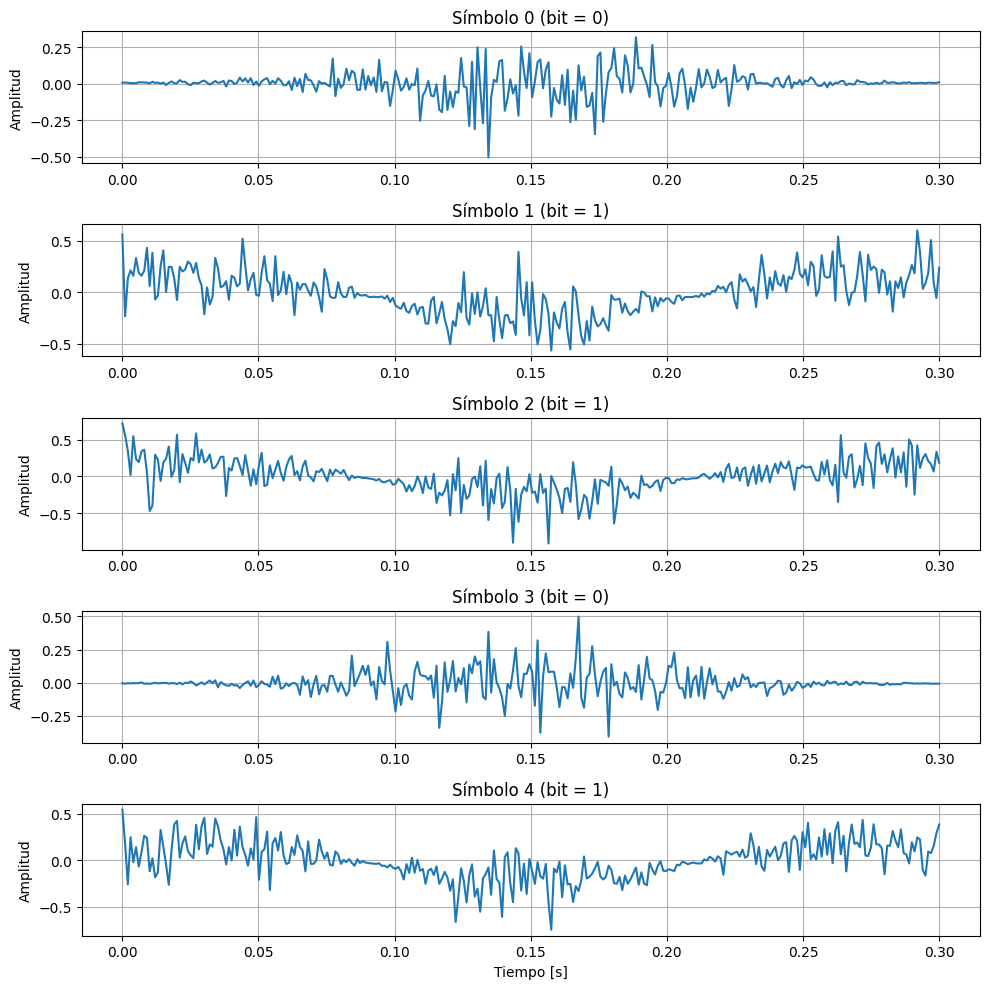

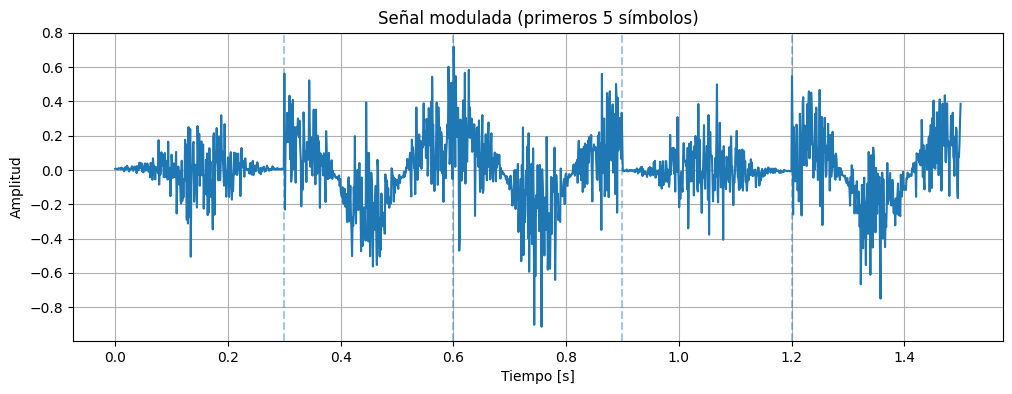

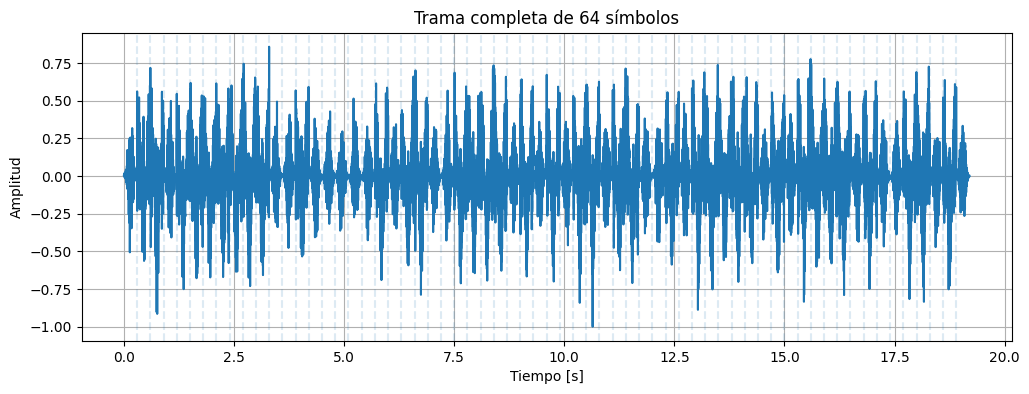

In [1]:
import torch
import math
import matplotlib.pyplot as plt

# ============ CONFIGURACIÓN ============
device = torch.device("cpu")
torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

# Parámetros del sistema
Fs, T_symbol = 1000.0, 0.3
N = int(Fs * T_symbol)
D0, D1 = 0.4, 1.0
N_symbols = 64

# Secuencia de bits y eje temporal
bits = torch.randint(0, 2, (N_symbols,), device=device)
t_symbol = torch.linspace(0.0, T_symbol, N, device=device)

# ============ ENVOLVENTES ============
center, sigma_env = T_symbol / 2.0, T_symbol / 6.0
env0 = torch.exp(-0.5 * ((t_symbol - center) / sigma_env) ** 2)
env0 = env0 / env0.max()
env1 = 0.5 - env0

# Factores de escala
A0 = 1.0 / D1
A1 = 1.0 / (math.sqrt(2.0 * math.pi) * D1 * D0)

# ============ GENERACIÓN DE SÍMBOLOS ============
def generate_symbol(bit: int) -> torch.Tensor:
    if bit == 0:
        symbol = A0 * torch.randn(N, device=device) * D0 * env0
    else:
        symbol = (A1 - torch.randn(N, device=device) * D1) * env1
    return symbol - symbol.mean()  # Media cero

# Generar 64 símbolos y normalizar globalmente
symbols = torch.stack([generate_symbol(int(b.item())) for b in bits])
symbols /= symbols.abs().max()

# ============ SEÑALES ============
signal_full = symbols.reshape(-1)
t_full = torch.linspace(0.0, N_symbols * T_symbol, len(signal_full), device=device)

# Primeros 5 símbolos
n_show = 5
symbols_first5 = symbols[:n_show]
signal_first5 = symbols_first5.reshape(-1)
t_first5 = torch.linspace(0.0, n_show * T_symbol, len(signal_first5), device=device)

# ============ VISUALIZACIÓN ============
# 1. Símbolos individuales
fig, axes = plt.subplots(n_show, 1, figsize=(10, 10))
for i, ax in enumerate(axes):
    ax.plot(t_symbol.cpu(), symbols_first5[i].cpu())
    ax.set_title(f"Símbolo {i} (bit = {bits[i].item()})")
    ax.set_ylabel("Amplitud")
    ax.grid(True)
axes[-1].set_xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()

# 2. Señal modulada (5 símbolos)
plt.figure(figsize=(12, 4))
plt.plot(t_first5.cpu(), signal_first5.cpu())
for k in range(1, n_show):
    plt.axvline(k * T_symbol, linestyle="--", alpha=0.4)
plt.title("Señal modulada (primeros 5 símbolos)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

# 3. Trama completa (64 símbolos)
plt.figure(figsize=(12, 4))
plt.plot(t_full.cpu(), signal_full.cpu())
for k in range(1, N_symbols):
    plt.axvline(k * T_symbol, linestyle="--", alpha=0.15)
plt.title("Trama completa de 64 símbolos")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


## Canal de Transmisión y Modelado del Ruido

La señal recibida en el canal está dada por:

$$
y(t) = x(d_i, t) + \eta(t)
$$

Donde:

* $x(d_i,t)$ es la señal transmitida, con $i \in \{0,1\}$.
* $\eta(t)$ es ruido aditivo blanco gaussiano (AWGN), con distribución:

$$
\eta(t) \sim \mathcal{N}(0, \sigma_\eta^2)
$$

Adicionalmente, el canal incluye un término de desplazamiento (offset) definido como:

$$
G = K \cdot \min\{D_0, D_1\}
$$

Donde:

* $K \approx 0.3$ es un factor de escala.
* $D_0$ y $D_1$ son parámetros asociados a la dispersión de las dos distribuciones de los símbolos.

Por lo tanto, la señal final recibida incorpora tanto el ruido gaussiano como este componente basado en la mínima dispersión entre los símbolos.

La forma final del canal se escribe como:

$$
y(t) = x(d_i,t) + \eta(t) + K \cdot \min\{D_0, D_1\}
$$

Este modelo permite estudiar cómo la presencia de ruido y el desplazamiento afectan la forma de onda recibida.

## Canal Aplicado a una Secuencia de 64 Símbolos

Sea el vector de datos:

$$
\mathbf{d} \in \{0,1\}^{64}
$$

Donde cada elemento del vector corresponde a un símbolo binario, tal que:

$$
d_i \in \{0,1\}, \quad i=1, \dots, 64
$$

Para cada símbolo $d_i$, la señal transmitida está dada por $x_i(t) = x(d_i, t)$. El canal afecta a cada forma de onda individual mediante la ecuación:

$$
y_i(t) = x_i(t) + \eta(t) + K \cdot \min\{D_0, D_1\}
$$

Donde:

* $\eta(t) \sim \mathcal{N}(0, \sigma_\eta^2)$ representa el componente de ruido.
* $K \approx 0.3$ es el factor de escala del término constante.

> **Nota de visualización:** En la gráfica siguiente solo se muestran las señales recibidas correspondientes a los **primeros 5 símbolos** de la secuencia total de 64.

/tmp/ipython-input-128632686.py:78: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  psd0_db = 10 * np.log10(psd0.cpu() + 1e-15)
/tmp/ipython-input-128632686.py:79: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  psd1_db = 10 * np.log10(psd1.cpu() + 1e-15)


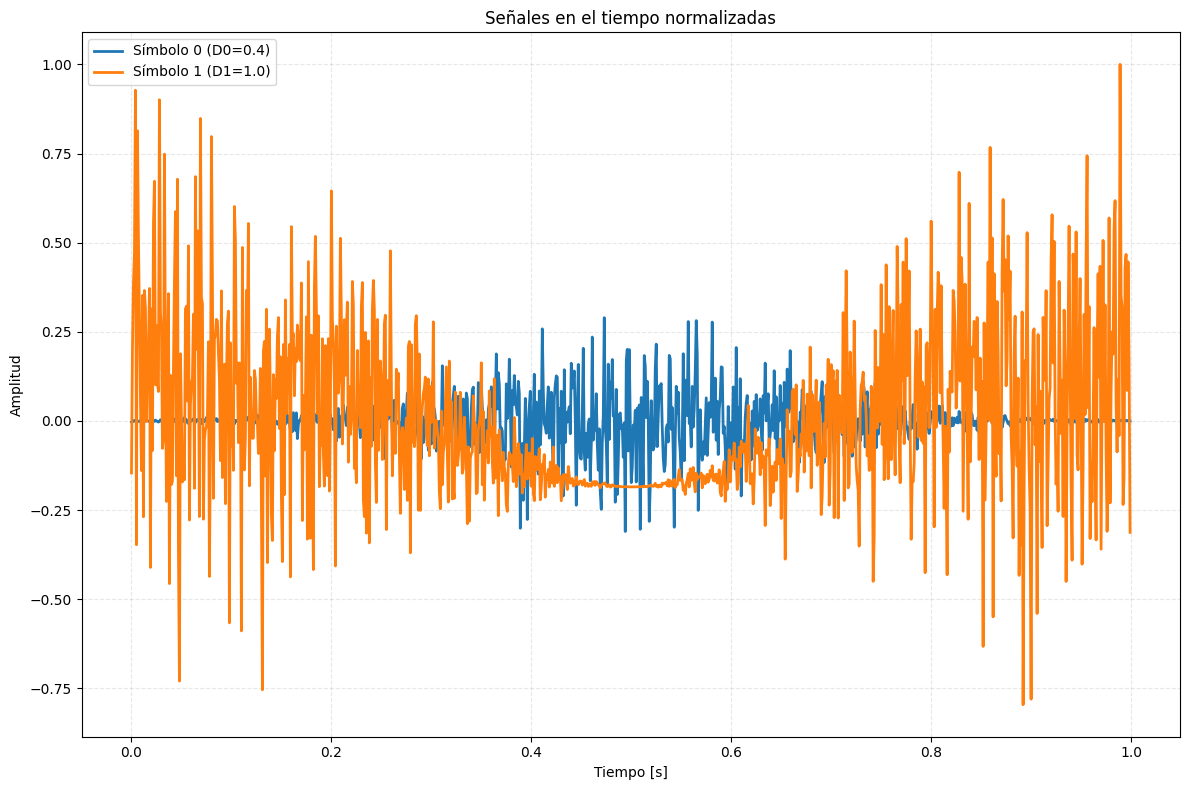

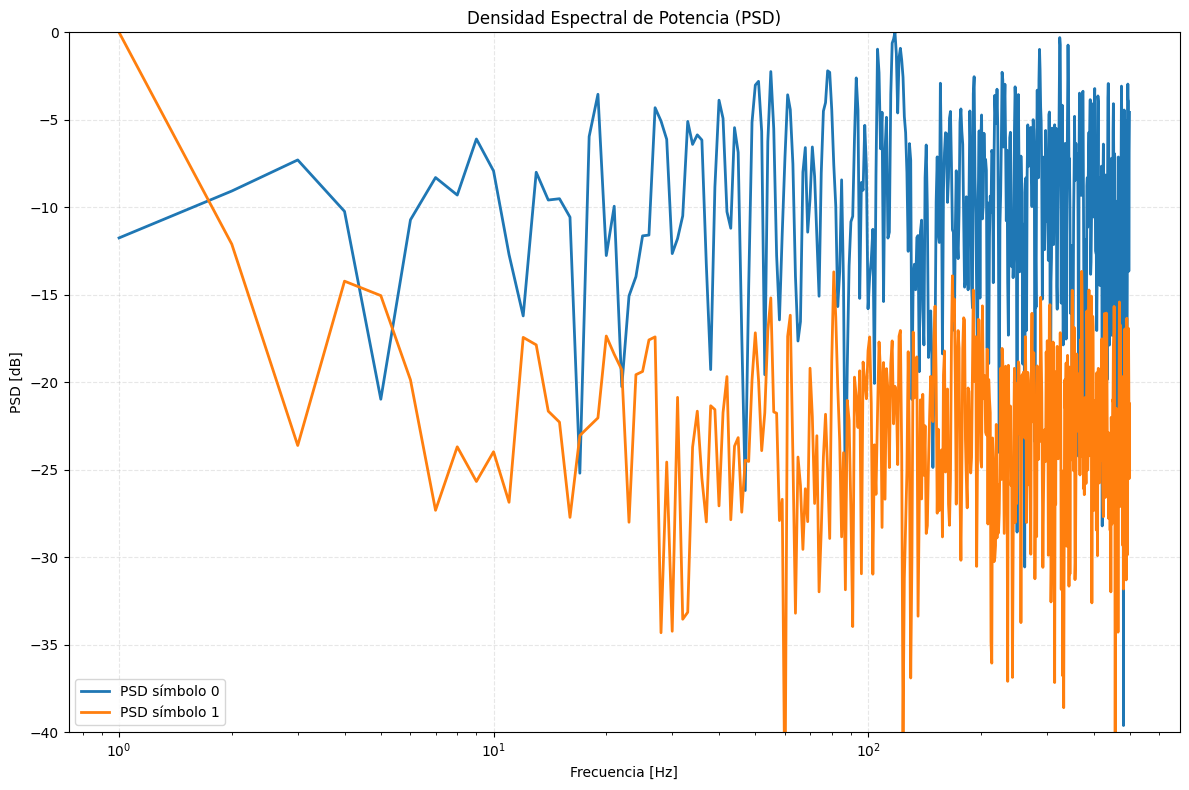

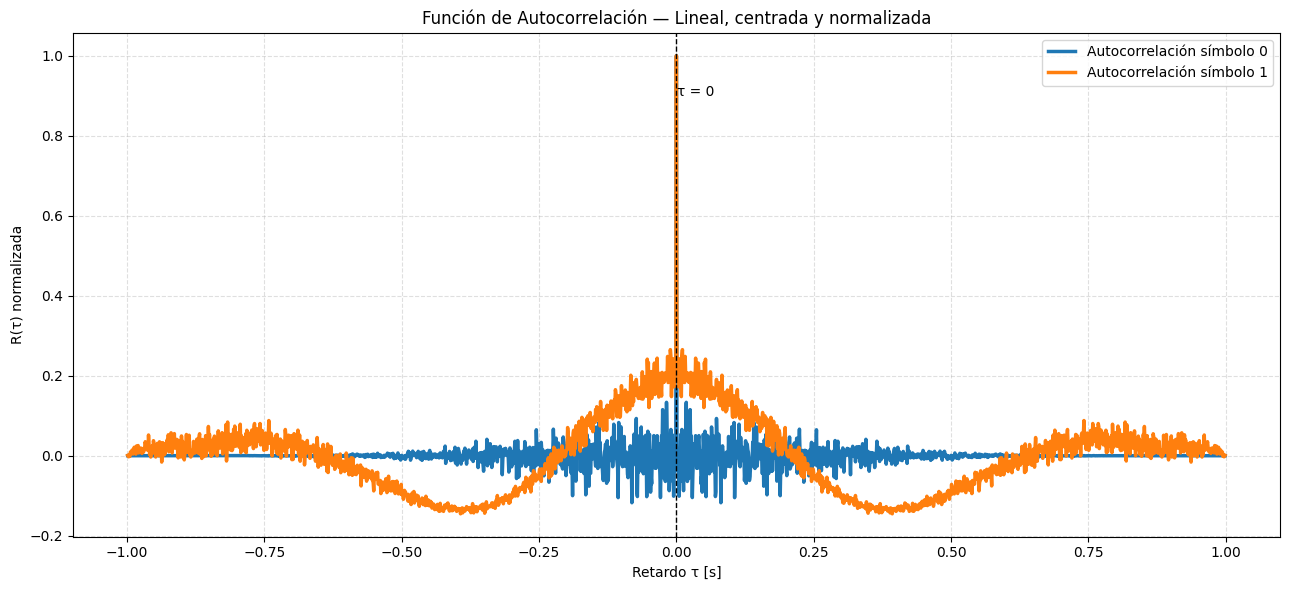

N = 1000 muestras — Fs = 1000.0 Hz — Ts = 1.00 ms
Media símbolo 0: 0.000000
Media símbolo 1: -0.000000
Max abs símbolos: 3.285877


In [5]:
import torch
import numpy as np
import math
import matplotlib.pyplot as plt

# ==========================================================
#                     CONFIGURACIÓN
# ==========================================================
device = torch.device("cpu")
torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

Fs = 1000.0          # Frecuencia de muestreo (Hz)
Ts = 1 / Fs          # Periodo
T_symbol = 1.0       # Duración del símbolo (1 s)
N = int(Fs * T_symbol)

# Parámetros D0 y D1
D0 = 0.4
D1 = 1.0

# Tiempo
t = torch.arange(0, N, device=device) * Ts

# ==========================================================
#                   ENVOLVENTES
# ==========================================================
center = T_symbol / 2
sigma_env = T_symbol / 6

env0 = torch.exp(-0.5 * ((t - center) / sigma_env) ** 2)
env0 /= env0.max()

env1 = 1.0 - env0

A0 = 1.0 / D1
A1 = 1.0 / (math.sqrt(2.0 * math.pi) * D1 * D0)

# ==========================================================
#            GENERACIÓN DE SÍMBOLOS
# ==========================================================
def generate_symbol(bit: int) -> torch.Tensor:
    if bit == 0:
        symbol = A0 * torch.randn(N, device=device) * D0 * env0
    else:
        symbol = (A1 - torch.randn(N, device=device) * D1) * env1
    return symbol


symbol0 = generate_symbol(0)
symbol1 = generate_symbol(1)

# ==========================================================
#     QUITAR MEDIA Y NORMALIZAR EN ESCALA COMÚN
# ==========================================================
symbol0 = symbol0 - symbol0.mean()
symbol1 = symbol1 - symbol1.mean()

max_abs = max(symbol0.abs().max(), symbol1.abs().max())
symbol0 /= max_abs
symbol1 /= max_abs

# ==========================================================
#                   PERIODOGRAMA
# ==========================================================
def psd_periodogram(x, fs):
    Nloc = len(x)
    X = torch.fft.fft(x)
    psd = (X.conj() * X).real / (Nloc * fs)
    freqs = torch.fft.fftfreq(Nloc, 1/fs)

    mask = freqs > 0
    return freqs[mask], psd[mask]

freqs0, psd0 = psd_periodogram(symbol0, Fs)
freqs1, psd1 = psd_periodogram(symbol1, Fs)

psd0_db = 10 * np.log10(psd0.cpu() + 1e-15)
psd1_db = 10 * np.log10(psd1.cpu() + 1e-15)

psd0_db -= psd0_db.max()
psd1_db -= psd1_db.max()

# ==========================================================
#           AUTOCORRELACIÓN PERFECTA
# ==========================================================
def autocorrelation_perfect(x: torch.Tensor, fs: float, normalized=True):
    x = x - x.mean()
    N = len(x)
    Npad = 2 * N

    Xf = torch.fft.fft(x, n=Npad)
    Rf = Xf * torch.conj(Xf)
    r = torch.fft.ifft(Rf).real

    r = torch.cat((r[-(N-1):], r[:N]))

    if normalized:
        r = r / r.max()

    lags = torch.arange(-(N-1), N, device=x.device)
    return lags, r

lags0, R0 = autocorrelation_perfect(symbol0, Fs)
lags1, R1 = autocorrelation_perfect(symbol1, Fs)

tau0 = lags0 / Fs
tau1 = lags1 / Fs

# ==========================================================
#                       GRAFICADO
# ==========================================================

plt.figure(figsize=(12, 8))
plt.plot(t.cpu(), symbol0.cpu(), label=f"Símbolo 0 (D0={D0})", linewidth=2)
plt.plot(t.cpu(), symbol1.cpu(), label=f"Símbolo 1 (D1={D1})", linewidth=2)
plt.grid(True, linestyle="--", alpha=0.3)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señales en el tiempo normalizadas")
plt.legend()
plt.tight_layout()
plt.show()

# ---- PSD ----
plt.figure(figsize=(12, 8))
plt.plot(freqs0.cpu(), psd0_db, label="PSD símbolo 0", linewidth=2)
plt.plot(freqs1.cpu(), psd1_db, label="PSD símbolo 1", linewidth=2)

plt.xscale("log")
plt.ylim([-40, 0])
plt.grid(True, linestyle="--", alpha=0.3)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.title("Densidad Espectral de Potencia (PSD)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- FUNCION DE AUTOCORRELACIÓN ----
plt.figure(figsize=(13, 6))
plt.plot(tau0.cpu(), R0.cpu(), label="Autocorrelación símbolo 0", linewidth=2.5)
plt.plot(tau1.cpu(), R1.cpu(), label="Autocorrelación símbolo 1", linewidth=2.5)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.text(0.002, 0.9, "τ = 0", color="black")

plt.grid(True, linestyle="--", alpha=0.4)
plt.xlabel("Retardo τ [s]")
plt.ylabel("R(τ) normalizada")
plt.title("Función de Autocorrelación — Lineal, centrada y normalizada")
plt.legend()
plt.tight_layout()
plt.show()

# ---- INFO ----
print(f"N = {N} muestras — Fs = {Fs} Hz — Ts = {Ts*1000:.2f} ms")
print(f"Media símbolo 0: {symbol0.mean():.6f}")
print(f"Media símbolo 1: {symbol1.mean():.6f}")
print(f"Max abs símbolos: {max_abs:.6f}")


#**Función de Autocorrelación**

# Función de Autocorrelación:

La **autocorrelación** de una señal discreta $x[n]$ describe **cuánta semejanza tiene la señal consigo misma** cuando es desplazada un cierto número de muestras. Se define directamente como la convolución:

$$
R_{xx}[\ell] = \sum_{n} x[n]\,x[n-\ell],
$$

donde $\ell$ es el **retardo (lag)**. El valor máximo $R_{xx}[0]$ siempre ocurre en $\ell = 0$.

---

## 1.  Cálculo Eficiente: El Teorema de Wiener–Khinchin

En el dominio de la frecuencia, la autocorrelación se relaciona con el espectro de potencia, permitiendo el cálculo vía FFT para mayor **velocidad** y **precisión** (el método tradicional):

$$
R_{xx}[\ell] = \mathcal{F}^{-1}\left\{ |X(f)|^2 \right\},
$$

donde $X(f)$ es la Transformada de Fourier de $x[n]$.

---

## 2.  Evitando la Distorsión: Uso del Zero-Padding

Para obtener la **autocorrelación lineal real** (y no la circular que ocurre si usamos la misma longitud $N$), es imprescindible extender la señal $x[n]$ con ceros (*zero-padding*).

* **Razón:** Evitar la superposición de valores (*aliasing*) en el dominio temporal.
* **Longitud Necesaria:** $N_{\text{pad}} = 2N$ (donde $N$ es la longitud original).

---

## 3.  Proceso Completo de Cálculo (Método FFT)

El cálculo profesional y eficiente sigue estos pasos:

### **(a) Eliminación de la Componente DC (Media)**
Se resta la media $\mu_x$ para evitar un pico artificial en $\ell=0$ que no representa la energía de la señal:
$$
x[n] \leftarrow x[n] - \mu_x
$$

### **(b) FFT sobre Señal *Zero-Padded***
Se aplica la FFT a la señal extendida de longitud $2N$:
$$
X[k] = \text{FFT}\{x[n]\}_{2N}
$$

### **(c) Obtención de la Densidad Espectral de Potencia**
Se calcula el cuadrado de la magnitud del espectro:
$$
|X[k]|^2 = X[k]\,X[k]^*
$$

### **(d) Aplicación de la IFFT**
Se regresa al dominio del tiempo para obtener el resultado simétrico:
$$
r[n] = \text{IFFT}\left\{|X[k]|^2\right\}
$$

### **(e) Extracción de la Parte Válida (Lags Lineales)**
De la salida de tamaño $2N$, la autocorrelación lineal verdadera tiene longitud $2N - 1$ y cubre los retardos:
$$
\ell = -(N-1),\dots,0,\dots,(N-1)
$$

### **(f) Normalización (Opcional)**
Si se requiere, se normaliza para que el pico máximo sea exactamente 1:
$$
R_{xx}[\ell] \leftarrow \frac{R_{xx}[\ell]}{R_{xx}[0]}
$$

---

## 4.  Interpretación Física y Temporal

* **Retardos en Segundos:** La escala de tiempo $\tau$ se obtiene dividiendo el lag $\ell$ por la frecuencia de muestreo $f_s$: $\tau = \frac{\ell}{f_s}$.
* **Valor en $\tau=0$:** Representa la energía total (o potencia media) de la señal.
* **Ancho del Pico Central:** Indica la **duración de la correlación temporal** de la señal (qué tan rápido "se olvida" de sí misma).
* **Oscilaciones Secundarias:** Revelan la presencia de periodicidades o componentes determinísticas dentro de la señal.

---

## Resumen
> La función `autocorrelation_perfect` calcula la autocorrelación lineal (no circular) mediante el eficiente Teorema de Wiener-Khinchin con *zero-padding* $2N$, extrayendo los lags correctos y normalizando el resultado para una representación profesional de $R_{xx}(\tau)$.

#**ESPECTRO NORMALIZADO, SEÑAL EN EL TIEMPO, FUNCION DE AUTOCORRELACION, ESPECTOGRAMA**

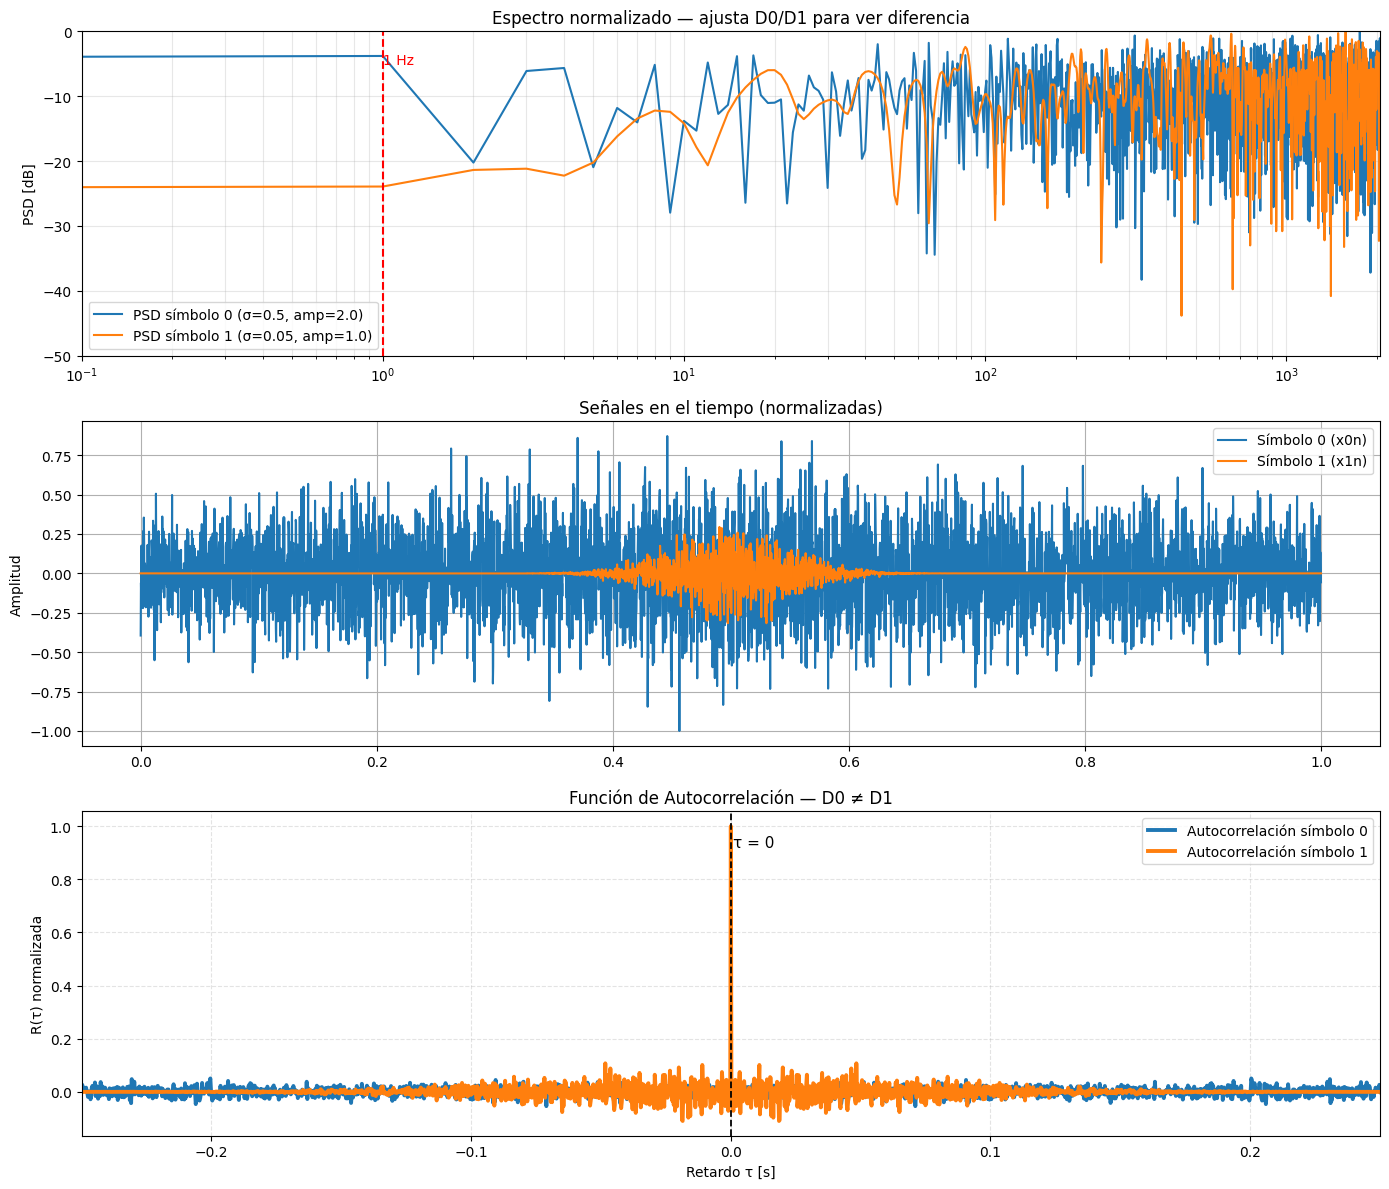

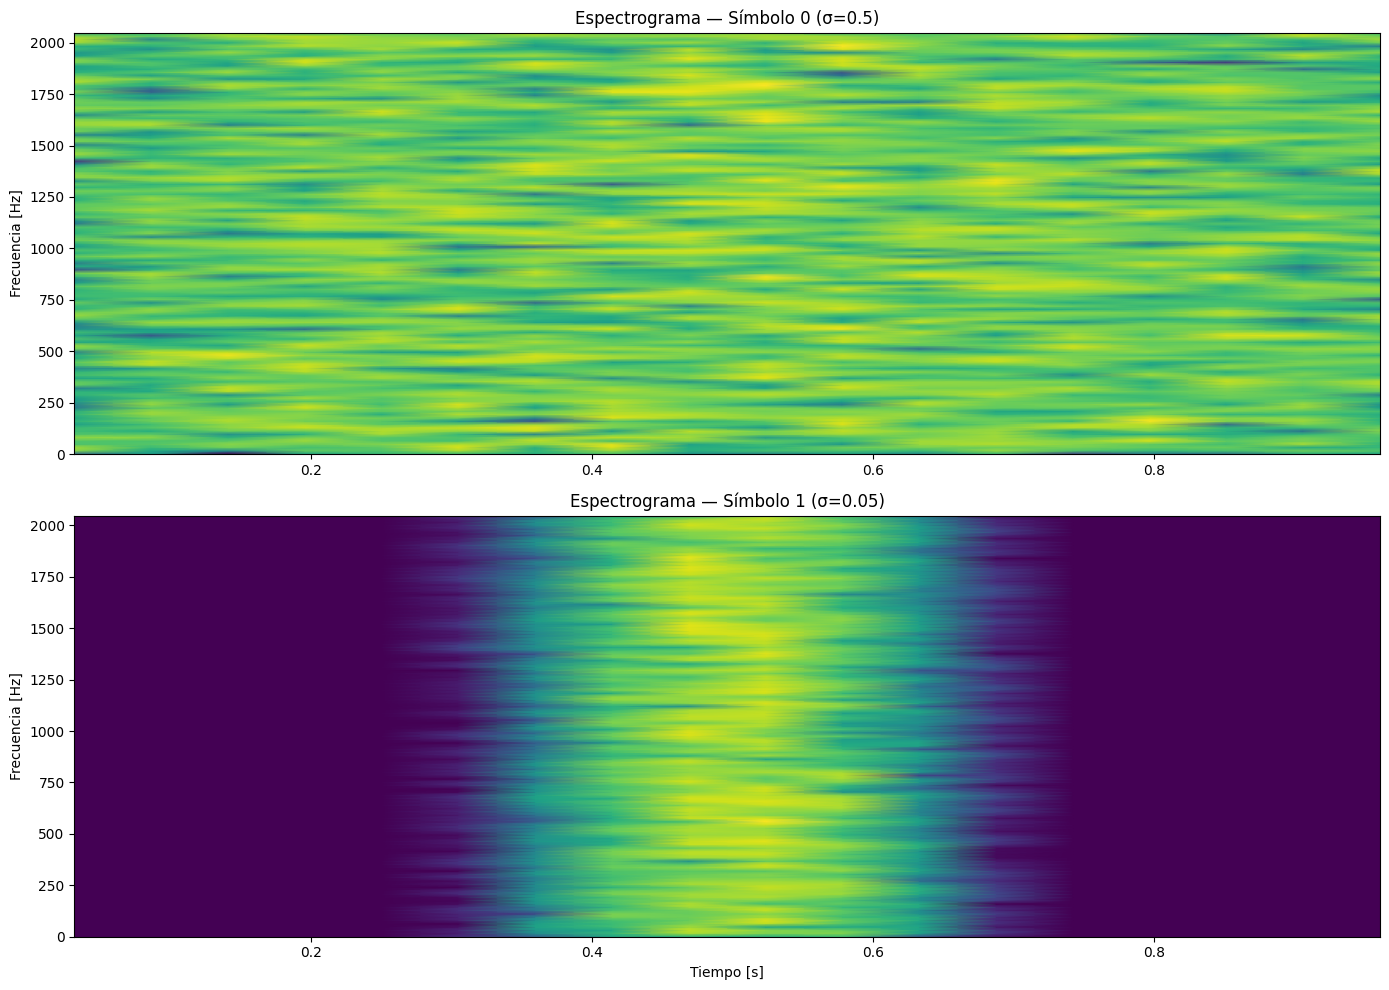

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# ============================================================
# CONFIGURACIÓN y PARÁMETROS EDITABLES (cámbialos aquí)
# ============================================================
torch.manual_seed(0)
np.random.seed(0)

Fs = 4096
T_symbol = 1.0
N = int(Fs * T_symbol)
t = torch.linspace(0, T_symbol, N)

# ---------- Parametros editables (cambia estos valores) ----------
# Anchura de las gaussianas (sigma) -> controla ancho de banda / auto-corr
D0_sigma = 0.5    # prueba 0.06 (muy estrecho) -> autocorr muy angosta
D1_sigma = 0.05    # prueba 0.20 (más estrecho), 0.6 (muy ancho)

# Amplitud multiplicativa de cada símbolo (antes de normalizar)
D0_amp = 2.0       # prueba 2.0, 0.5, etc.
D1_amp = 1.0

# Si prefieres ver R(0) distinto para cada símbolo, pon False (no normalizar conjunto)
NORMALIZE_GLOBAL = True
# ==================================================================

# ============================================================
# Envolventas gaussianas escaladas por amplitud
# ============================================================
def gauss_env_sigma(t, sigma):
    g = torch.exp(- (t - 0.5)**2 / (2 * sigma**2))
    return g / g.max()

sigma0_t = D0_amp * gauss_env_sigma(t, D0_sigma)
sigma1_t = D1_amp * gauss_env_sigma(t, D1_sigma)

# ============================================================
# GENERAR SEÑALES EN EL TIEMPO (ruido blanco modulada por la envolvente)
# ============================================================
w0 = torch.randn(N)
w1 = torch.randn(N)

x0 = sigma0_t * w0
x1 = sigma1_t * w1

# remover DC
x0 -= x0.mean()
x1 -= x1.mean()

# normalizar amplitudes (opcional)
if NORMALIZE_GLOBAL:
    scale = max(x0.abs().max(), x1.abs().max())
    x0n = x0 / scale
    x1n = x1 / scale
else:
    # normalización individual (mantiene R(0) proporcional a energia)
    x0n = x0 / x0.abs().max()
    x1n = x1 / x1.abs().max()

# ============================================================
# AUTOCORRELACIÓN (completa, normalizada por su pico)
# ============================================================
def autocorr_full(x, Fs):
    arr = x.numpy()
    R = np.correlate(arr, arr, mode="full")
    R = R / np.max(np.abs(R))   # normaliza cada autocorrelación a su pico = 1
    Nl = len(arr)
    lags = np.arange(-Nl+1, Nl) / Fs
    return R, lags

R0, lags0 = autocorr_full(x0n, Fs)
R1, lags1 = autocorr_full(x1n, Fs)

# corregir punto de fuga en tau=0 si aparece
idx0 = np.where(lags0 == 0)[0]
if len(idx0) > 0:
    i = idx0[0]
    if 0 < i < len(R0)-1:
        R0[i] = 0.5 * (R0[i-1] + R0[i+1])

# ============================================================
# ESPECTROGRAMA (STFT)
# ============================================================
f0_s, t0_s, Sxx0 = spectrogram(x0n.numpy(), fs=Fs, nperseg=256, window='hann')
f1_s, t1_s, Sxx1 = spectrogram(x1n.numpy(), fs=Fs, nperseg=256, window='hann')

# ============================================================
# PERIODOGRAMA (dB)
# ============================================================
def periodogram_dB(x, Fs):
    Nvec = x.numel()
    Xf = torch.fft.rfft(x)
    PSD = (1/(Fs * Nvec)) * torch.abs(Xf)**2
    PSD = PSD / PSD.max()
    PSD_dB = 10 * torch.log10(PSD + 1e-12)
    freqs = torch.linspace(0, Fs/2, PSD.numel())
    return freqs, PSD_dB

f0_p, PSD0 = periodogram_dB(x0n, Fs)
f1_p, PSD1 = periodogram_dB(x1n, Fs)

# ============================================================
# GRAFICAR TODO (PSD, señales en tiempo, autocorrelación)
# ============================================================
plt.figure(figsize=(14,12))

# PSD
plt.subplot(3,1,1)
plt.plot(f0_p, PSD0, label=f"PSD símbolo 0 (σ={D0_sigma}, amp={D0_amp})")
plt.plot(f1_p, PSD1, label=f"PSD símbolo 1 (σ={D1_sigma}, amp={D1_amp})")
plt.xscale("log")
plt.ylim([-50, 0])
plt.xlim([1e-1, Fs/2])
plt.axvline(1, color="red", linestyle="--")
plt.text(1, -5, "1 Hz", color="red", fontsize=10)
plt.grid(True, which="both", alpha=0.3)
plt.ylabel("PSD [dB]")
plt.title("Espectro normalizado — ajusta D0/D1 para ver diferencia")
plt.legend()

# Señales en el tiempo
plt.subplot(3,1,2)
plt.plot(t.numpy(), x0n.numpy(), label="Símbolo 0 (x0n)")
plt.plot(t.numpy(), x1n.numpy(), label="Símbolo 1 (x1n)")
plt.grid(True)
plt.ylabel("Amplitud")
plt.title("Señales en el tiempo (normalizadas)")
plt.legend()

# Autocorrelación
plt.subplot(3,1,3)
plt.plot(lags0, R0, label="Autocorrelación símbolo 0", linewidth=2.8)
plt.plot(lags1, R1, label="Autocorrelación símbolo 1", linewidth=2.8)
plt.axvline(0, color="black", linestyle="--", linewidth=1.3)
plt.text(0.001, 0.92, "τ = 0", color="black", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.35)
plt.xlabel("Retardo τ [s]")
plt.ylabel("R(τ) normalizada")
plt.title("Función de Autocorrelación — D0 ≠ D1")
plt.xlim([-0.25, 0.25])
plt.legend()
plt.tight_layout()
plt.show()

# ESPECTROGRAMAS
plt.figure(figsize=(14,10))
plt.subplot(2,1,1)
plt.pcolormesh(t0_s, f0_s, 10*np.log10(Sxx0 + 1e-12), shading='gouraud')
plt.title(f"Espectrograma — Símbolo 0 (σ={D0_sigma})")
plt.ylabel("Frecuencia [Hz]")

plt.subplot(2,1,2)
plt.pcolormesh(t1_s, f1_s, 10*np.log10(Sxx1 + 1e-12), shading='gouraud')
plt.title(f"Espectrograma — Símbolo 1 (σ={D1_sigma})")
plt.ylabel("Frecuencia [Hz]")
plt.xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()


#  Análisis Detallado de Señales y Gráficas $D_0 = D_1$

El experimento se basa en la condición de simetría $\mathbf{D_0 = D_1 = 1}$, lo que implica que las dos señales informativas $\mathbf{x_0(t)}$ y $\mathbf{x_1(t)}$ tienen la **misma estructura estadística** y están moduladas por la misma **envolvente gaussiana** $\sigma(t)$.

---

## 1.  Generación de Señales Base y Condición de Simetría

* **Definición del Experimento:**
    * $D_0 = 1$ y $D_1 = 1$.
    * Señales generadas: $x_0(t) = \sigma_0(t)\, w_0(t)$ y $x_1(t) = \sigma_1(t)\, w_1(t)$.
* **Parámetros Comunes:** $w_0$ y $w_1$ son realizaciones de ruido gaussiano. $\sigma(t)$ es la misma envolvente gaussiana.
* **Implicación:** Las dos señales tienen la misma envolvente, la misma dispersión y se espera que tengan el mismo contenido energético y ancho de banda. La normalización posterior elimina la componente DC y asegura la misma amplitud máxima.

---

## 2.  Gráfica 1: Densidad Espectral de Potencia (PSD) Normalizada

| ¿Qué se ve? | ¿Qué significa? (Rigor Científico) | Conclusión Clave |
| :--- | :--- | :--- |
| **Espectros Superpuestos:** Ambas señales tienen curvas espectrales casi idénticas en el rango dinámico de $-40 \text{ dB}$ a $0 \text{ dB}$. | La **similitud espectral** es una consecuencia directa de la condición $\mathbf{D_0 = D_1}$ y el uso de la misma envolvente $\sigma(t)$, que actúa como un **filtro paso bajo** sobre el ruido blanco. | La PSD confirma que **ambas señales poseen el mismo ancho de banda** y no hay diferencias estructurales entre los símbolos. La envolvente gaussiana controla el ancho de banda y suaviza el espectro. |
| **Caída Suave:** El espectro cae suavemente desde bajas frecuencias. | **Propiedad de la Envolvente:** La multiplicación por la envolvente gaussiana en el tiempo se traduce en una **convolución** en frecuencia con una función Gaussiana. Esto explica el espectro suavizado y la ausencia de componentes espectrales abruptas. | **Filtro Implícito:** La modulación por $\sigma(t)$ impone una limitación de ancho de banda. |

---

## 3.  Gráfica 2: Señal en el Tiempo

| ¿Qué se ve? | ¿Interpretación Ingenieril? | Conclusión Clave |
| :--- | :--- | :--- |
| **Concentración Central de Energía:** La mayor energía y amplitud ocurren alrededor de $t=0.5 \text{ s}$. | **Efecto de la Envolvente:** Esto es el resultado directo de la multiplicación por $\sigma(t)$, que modula la amplitud del ruido gaussiano. | La gráfica confirma la **modulación temporal correcta** por la envolvente y la estricta **normalización** de las señales. |
| **Diferencias Mínimas:** Las dos formas de onda son distintas punto por punto, pero tienen la misma forma global. | **Realizaciones de Ruido:** Las diferencias se deben exclusivamente a que $w_0(t)$ y $w_1(t)$ son **realizaciones aleatorias diferentes** del mismo proceso estocástico (ruido gaussiano). | Se reconfirma que, más allá de la aleatoriedad, la estructura temporal de $\mathbf{x_0}$ y $\mathbf{x_1}$ es idéntica. |

---

## 4.  Gráfica 3: Autocorrelación Normalizada

| Fómula de Referencia | ¿Qué se ve? | Conclusión Clave |
| :--- | :--- | :--- |
| $R_{xx}(\tau) = \frac{1}{R_{xx}(0)} \sum_n x[n] \, x[n+\tau]$ | **Curvas Idénticas y Suaves:** Una curva centrada y de caída suave (gaussiana), que alcanza $R_{xx}(0)=1$ debido a la normalización. | La autocorrelación revela que la señal es **ruido filtrado** y no ruido blanco puro. La duración del pico está inversamente relacionada con el ancho de banda visto en la PSD. |
| **Simetría Total:** Las curvas de $\mathbf{x_0}$ y $\mathbf{x_1}$ son prácticamente indistinguibles. | **Estructura Interna Común:** La estructura temporal intrínseca (no la aleatoriedad) es la misma. Esto se debe a que la estadística del ruido y la envolvente son comunes. | La estructura temporal de **ambas señales es la misma**, confirmando la **simetría del sistema** cuando $D_0 = D_1$. |

---

## 5.  Gráfica 4: Espectrograma (STFT)

| ¿Qué se ve? | ¿Qué significa? (Dominio Tiempo-Frecuencia) | Conclusión Clave |
| :--- | :--- | :--- |
| **Concentración de Energía:** La energía está focalizada tanto en el centro del tiempo ($t \approx 0.5 \text{ s}$) como en las bajas frecuencias ($\sim 0 \text{ Hz}$ hasta $400-500 \text{ Hz}$). | **No Estacionariedad:** La energía no es constante en el tiempo, lo que significa que la señal es **no estacionaria** (propiedad debida a la envolvente $\sigma(t)$). La limitación de frecuencia es coherente con la PSD. | **Similitud Tiempo-Frecuencia:** Las dos imágenes del espectrograma son casi idénticas, lo que confirma que el comportamiento de $\mathbf{x_0}$ y $\mathbf{x_1}$ en el espacio tiempo-frecuencia es el mismo. |
| **Ausencia de Picos o Trazas:** No se observan trazas determinísticas claras (como las de tonos puros). | **Naturaleza Estocástica:** La señal es ruido blanco multiplicado por una envolvente. Su carácter es **estocástico**, lo que se refleja en una distribución de energía suave y difusa. | El espectrograma es la confirmación más robusta de que $\mathbf{x_0}$ y $\mathbf{x_1}$ son estadísticamente equivalentes bajo la condición $\mathbf{D_0 = D_1}$. |

---

##  Conclusión Global del Experimento

El análisis en los tres dominios (Tiempo, Frecuencia, Tiempo-Frecuencia) concluye de manera inequívoca que la condición $\mathbf{D_0 = D_1}$ crea un sistema completamente **simétrico**. Todas las diferencias observadas son **marginales** y se deben exclusivamente a la distinta realización del ruido.

**Implicación Clave:** No es posible distinguir el **símbolo 0** del **símbolo 1** basándose en la estructura estadística de las señales cuando $D_0 = D_1$.

¿Te gustaría que analicemos el caso asimétrico, por ejemplo, cuando $D_0 \ne D_1$, para ver cómo cambian estas gráficas?

#  **Explicación del Espectrograma :**
El **espectrograma** es la herramienta fundamental para visualizar la **evolución del contenido en frecuencia** de una señal a lo largo del tiempo. La función `spectrogram_perfect` utiliza la **Short-Time Fourier Transform (STFT)** y técnicas de *windowing* para lograr una representación estable y sin artefactos.

---

## 1. Preprocesamiento y *Windowing* (Ventaneo)

| Código | Propósito Ingenieril |
| :--- | :--- |
| `x = x - x.mean()` | **Eliminación de la Componente DC (Media):** Evita la concentración artificial de energía en las frecuencias bajas ($f \approx 0$). Esto asegura que el espectrograma muestre la energía de la señal modulada, no la polarización. |
| `win = torch.hann_window(n_fft)` | **Ventana de Hann:** Se genera la ventana. Esta función es estándar para reducir las **fugas espectrales** (*spectral leakage*), lo que mejora la resolución en frecuencia y minimiza los artefactos en el espectrograma. |
| `win = win / torch.sqrt(torch.sum(win**2))` | **Normalización de la Ventana:** Se normaliza la ventana para garantizar que cada segmento de la señal (cada ventana) contribuya con la **misma cantidad de energía**. Esto evita cambios de brillo no deseados a lo largo del eje del tiempo. |

---

## 2. Cálculo de la Transformada (STFT)

| Código | Propósito Ingenieril |
| :--- | :--- |
| `stft_output = torch.stft(x, ...)` | **Cálculo de la STFT:** La STFT divide la señal en ventanas solapadas (controlado por el parámetro `hop`) y aplica la FFT a cada segmento. Esto transforma la señal unidimensional ($x[n]$) en una matriz compleja. |
| **Matriz Resultante:** | Esta matriz (bidimensional) organiza los datos de la siguiente manera: **Columnas** $\rightarrow$ **Tiempo** (progresión del segmento). **Filas** $\rightarrow$ **Frecuencia** (bins de la FFT). |

---

## 3. Conversión a Magnitud en Decibelios (dB)

| Código | Propósito Ingenieril |
| :--- | :--- |
| `S = torch.abs(stft_output)` | **Magnitud Espectral:** Se calcula el valor absoluto de la matriz compleja para obtener la magnitud. |
| `S_db = 20 * torch.log10(S + 1e-12)` | **Conversión a Decibelios (dB):** Se usa la relación $20 \log_{10}(S)$. La pequeña constante $10^{-12}$ se añade para evitar el logaritmo de cero, asegurando la estabilidad numérica. La escala dB es esencial para **resaltar las componentes débiles** y permitir la visualización de la estructura espectral fina. |

---

## 4. Calibración de Ejes y Visualización

* **Ejes Correctos:** Los vectores de frecuencia (`freqs`) y tiempo (`times`) se calibran usando la frecuencia de muestreo $f_s$ y el tamaño del *hop* para garantizar que la visualización esté correctamente etiquetada en **Hz** y **segundos**.
* **Visualización Profesional:** Se emplean parámetros como `viridis` (mapa de colores perceptualmente uniforme), `aspect='auto'` (evita deformación) y `origin='lower'` (frecuencias crecientes hacia arriba), que son prácticas estándar para una representación científica y clara.

---

## 5. Interpretación

El espectrograma final permite observar claramente características críticas para el análisis de señales moduladas:

* **Varianza de Energía por Frecuencia:** ¿Dónde se concentra la potencia?
* **Estabilidad Temporal de los Símbolos:** ¿Qué tan constante es el espectro a lo largo de la duración de cada símbolo?
* **Detección de Estructura:** ¿Existen diferencias claras entre los símbolos (ej., más ruido en el Símbolo '0' vs. más estructura en el Símbolo '1')?
* **Ancho de Banda Efectivo:** Permite medir visualmente la ocupación espectral de la señal.

#**REGION DE UMBRAL + FILTRO DE ACOPLAMIENTO**

VERIFICACIÓN DE COMPONENTE DC EN PLANTILLAS
Media plantilla h₀(t): 3.52e-19
Media plantilla h₁(t): -1.25e-19
Energía E₀ = 245.4263 → normalizada a 1.0
Energía E₁ = 7.4305 → normalizada a 1.0

GENERANDO ESTADÍSTICAS DEL DETECTOR

DC promedio en señales H₀: -5.40e-19 ± 1.97e-17
DC promedio en señales H₁: 8.57e-20 ± 1.65e-18

✓ Método: Umbral Óptimo (Mínimo Pe)
  SNR = 10.0 dB
  Umbral λ = -0.0304

────────────────────────────────────────────────────────────
MÉTRICAS DE DESEMPEÑO
────────────────────────────────────────────────────────────
  Probabilidad de Falsa Alarma (PFA): 0.5300
  Probabilidad de Detección (PD):     0.5700
  Probabilidad de Pérdida (PMD):      0.4300
  Probabilidad de Error (Pe):         0.4800
────────────────────────────────────────────────────────────



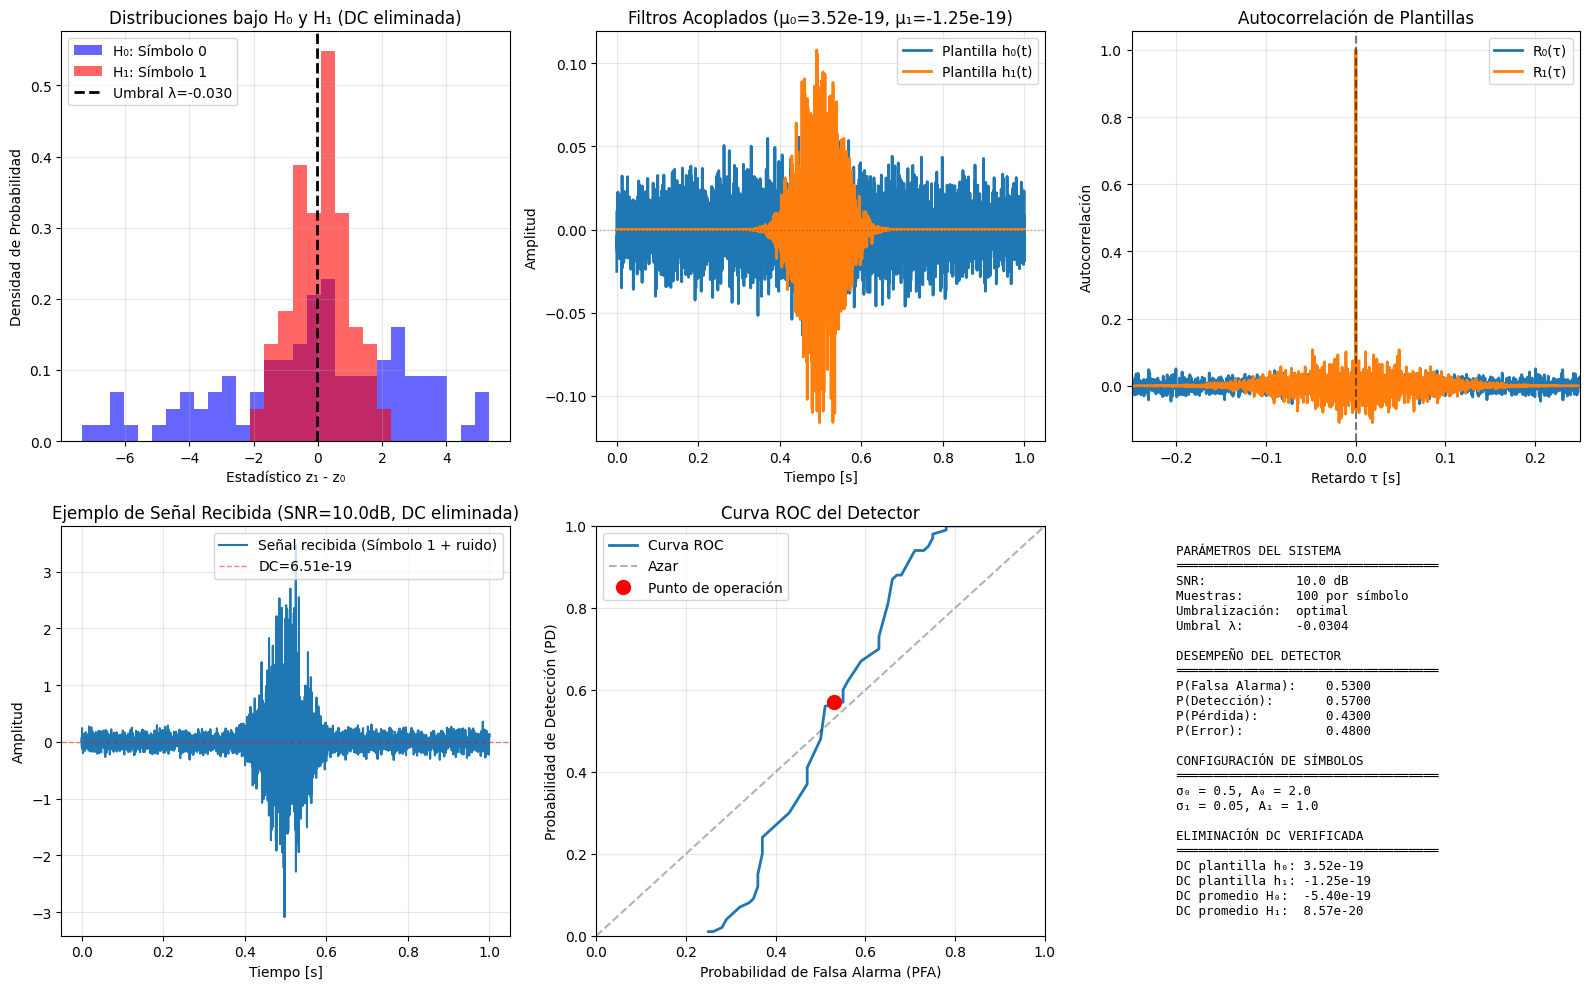


DETECTOR DE ACOPLADO CON ELIMINACIÓN DC IMPLEMENTADO
✓ Componente DC eliminada en plantillas
✓ Componente DC eliminada en señales limpias
✓ Componente DC eliminada en ruido
✓ Componente DC eliminada en señales recibidas
✓ Estadístico de decisión: z = z₁ - z₀
✓ Regla de decisión: decidir H₁ si z ≥ λ = -0.0304
✓ Desempeño: Pe = 0.4800 a SNR = 10.0 dB


In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# ============================================================
# CONFIGURACIÓN y PARÁMETROS EDITABLES
# ============================================================
torch.manual_seed(0)
np.random.seed(0)

Fs = 4096
T_symbol = 1.0
N = int(Fs * T_symbol)
t = torch.linspace(0, T_symbol, N)

# Parámetros de símbolos
D0_sigma = 0.5
D1_sigma = 0.05
D0_amp = 2.0
D1_amp = 1.0
NORMALIZE_GLOBAL = True

# ============================================================
# PARÁMETROS DEL DETECTOR
# ============================================================
SNR_dB = 10.0  # Relación señal-ruido en dB para pruebas
N_TEST = 100   # Número de símbolos de prueba
THRESHOLD_METHOD = 'optimal'  # 'optimal', 'fixed', 'neyman_pearson'
PFA_TARGET = 0.01  # Probabilidad de falsa alarma (para Neyman-Pearson)

# ============================================================
# GENERACIÓN DE SÍMBOLOS BASE
# ============================================================
def gauss_env_sigma(t, sigma):
    g = torch.exp(- (t - 0.5)**2 / (2 * sigma**2))
    return g / g.max()

sigma0_t = D0_amp * gauss_env_sigma(t, D0_sigma)
sigma1_t = D1_amp * gauss_env_sigma(t, D1_sigma)

# Generar símbolos de referencia (plantillas para filtro acoplado)
w0_ref = torch.randn(N)
w1_ref = torch.randn(N)

x0_ref = sigma0_t * w0_ref
x1_ref = sigma1_t * w1_ref

# ============================================================
# ELIMINACIÓN DE COMPONENTE DC EN PLANTILLAS
# ============================================================
x0_ref -= x0_ref.mean()
x1_ref -= x1_ref.mean()

if NORMALIZE_GLOBAL:
    scale = max(x0_ref.abs().max(), x1_ref.abs().max())
    x0_ref = x0_ref / scale
    x1_ref = x1_ref / scale
else:
    x0_ref = x0_ref / x0_ref.abs().max()
    x1_ref = x1_ref / x1_ref.abs().max()

# Normalizar energía de plantillas
E0 = torch.sum(x0_ref**2)
E1 = torch.sum(x1_ref**2)
x0_ref = x0_ref / torch.sqrt(E0)
x1_ref = x1_ref / torch.sqrt(E1)

# Verificar eliminación DC en plantillas
print("=" * 60)
print("VERIFICACIÓN DE COMPONENTE DC EN PLANTILLAS")
print("=" * 60)
print(f"Media plantilla h₀(t): {x0_ref.mean().item():.2e}")
print(f"Media plantilla h₁(t): {x1_ref.mean().item():.2e}")
print(f"Energía E₀ = {E0.item():.4f} → normalizada a 1.0")
print(f"Energía E₁ = {E1.item():.4f} → normalizada a 1.0")

# ============================================================
# FILTRO ACOPLADO (MATCHED FILTER)
# ============================================================
def matched_filter_output(received_signal, template):
    """
    Calcula la salida del filtro acoplado.
    Salida = correlación cruzada en el punto de decisión (final del símbolo)
    """
    return torch.sum(received_signal * template)

# ============================================================
# GENERACIÓN DE SEÑALES DE PRUEBA CON RUIDO
# ============================================================
def generate_test_symbol(symbol_type, snr_dB):
    """
    Genera símbolo de prueba con ruido AWGN
    symbol_type: 0 o 1
    """
    if symbol_type == 0:
        sigma_t = sigma0_t
        w = torch.randn(N)
        x_clean = sigma_t * w
    else:
        sigma_t = sigma1_t
        w = torch.randn(N)
        x_clean = sigma_t * w

    # ============================================================
    # ELIMINACIÓN DE COMPONENTE DC EN SEÑAL LIMPIA
    # ============================================================
    x_clean -= x_clean.mean()

    # Normalización
    if NORMALIZE_GLOBAL:
        scale = max(x0_ref.abs().max() * torch.sqrt(E0),
                    x1_ref.abs().max() * torch.sqrt(E1))
        x_clean = x_clean / scale
    else:
        x_clean = x_clean / x_clean.abs().max()

    # Añadir ruido AWGN
    signal_power = torch.mean(x_clean**2)
    snr_linear = 10**(snr_dB/10)
    noise_power = signal_power / snr_linear
    noise = torch.randn(N)

    # ============================================================
    # ELIMINACIÓN DE COMPONENTE DC EN RUIDO
    # ============================================================
    noise -= noise.mean()
    noise = torch.sqrt(noise_power) * noise / torch.sqrt(torch.mean(noise**2))

    x_noisy = x_clean + noise

    # ============================================================
    # ELIMINACIÓN DE COMPONENTE DC EN SEÑAL RECIBIDA FINAL
    # ============================================================
    x_noisy -= x_noisy.mean()

    return x_noisy

# ============================================================
# CÁLCULO DE ESTADÍSTICAS PARA UMBRALIZACIÓN
# ============================================================
print("\n" + "=" * 60)
print("GENERANDO ESTADÍSTICAS DEL DETECTOR")
print("=" * 60)

# Generar muestras de entrenamiento para estimar distribuciones
outputs_H0 = []  # H0: símbolo 0 transmitido
outputs_H1 = []  # H1: símbolo 1 transmitido

# Verificadores de DC en señales de prueba
dc_checks_H0 = []
dc_checks_H1 = []

for i in range(N_TEST):
    # Generar símbolo 0 y calcular estadístico de decisión
    x_test = generate_test_symbol(0, SNR_dB)
    dc_checks_H0.append(x_test.mean().item())
    z0 = matched_filter_output(x_test, x0_ref).item()
    z1 = matched_filter_output(x_test, x1_ref).item()
    decision_stat = z1 - z0  # Estadístico de razón de verosimilitud
    outputs_H0.append(decision_stat)

    # Generar símbolo 1 y calcular estadístico de decisión
    x_test = generate_test_symbol(1, SNR_dB)
    dc_checks_H1.append(x_test.mean().item())
    z0 = matched_filter_output(x_test, x0_ref).item()
    z1 = matched_filter_output(x_test, x1_ref).item()
    decision_stat = z1 - z0
    outputs_H1.append(decision_stat)

outputs_H0 = np.array(outputs_H0)
outputs_H1 = np.array(outputs_H1)

# Verificación de DC en señales de prueba
print(f"\nDC promedio en señales H₀: {np.mean(dc_checks_H0):.2e} ± {np.std(dc_checks_H0):.2e}")
print(f"DC promedio en señales H₁: {np.mean(dc_checks_H1):.2e} ± {np.std(dc_checks_H1):.2e}")

# ============================================================
# UMBRALIZACIÓN
# ============================================================
if THRESHOLD_METHOD == 'optimal':
    # Umbral óptimo (minimiza probabilidad de error)
    threshold = (np.mean(outputs_H0) + np.mean(outputs_H1)) / 2
    print(f"\n✓ Método: Umbral Óptimo (Mínimo Pe)")

elif THRESHOLD_METHOD == 'neyman_pearson':
    # Criterio Neyman-Pearson: fija PFA, maximiza PD
    threshold = np.percentile(outputs_H0, (1 - PFA_TARGET) * 100)
    print(f"\n✓ Método: Neyman-Pearson (PFA = {PFA_TARGET})")

else:  # 'fixed'
    threshold = 0.0
    print(f"\n✓ Método: Umbral Fijo = 0")

print(f"  SNR = {SNR_dB} dB")
print(f"  Umbral λ = {threshold:.4f}")

# ============================================================
# EVALUACIÓN DEL DETECTOR
# ============================================================
# Detecciones correctas e incorrectas
correct_0 = np.sum(outputs_H0 < threshold)
correct_1 = np.sum(outputs_H1 >= threshold)

false_alarm = N_TEST - correct_0  # Detectó 1 cuando era 0
miss = N_TEST - correct_1          # Detectó 0 cuando era 1

PFA = false_alarm / N_TEST
PMD = miss / N_TEST
PD = 1 - PMD
Pe = (PFA + PMD) / 2

print(f"\n{'─'*60}")
print("MÉTRICAS DE DESEMPEÑO")
print(f"{'─'*60}")
print(f"  Probabilidad de Falsa Alarma (PFA): {PFA:.4f}")
print(f"  Probabilidad de Detección (PD):     {PD:.4f}")
print(f"  Probabilidad de Pérdida (PMD):      {PMD:.4f}")
print(f"  Probabilidad de Error (Pe):         {Pe:.4f}")
print(f"{'─'*60}\n")

# ============================================================
# VISUALIZACIÓN
# ============================================================
fig = plt.figure(figsize=(16, 10))

# 1. Distribuciones del estadístico de decisión
ax1 = plt.subplot(2, 3, 1)
bins = np.linspace(min(outputs_H0.min(), outputs_H1.min()),
                   max(outputs_H0.max(), outputs_H1.max()), 30)
plt.hist(outputs_H0, bins=bins, alpha=0.6, label='H₀: Símbolo 0',
         color='blue', density=True)
plt.hist(outputs_H1, bins=bins, alpha=0.6, label='H₁: Símbolo 1',
         color='red', density=True)
plt.axvline(threshold, color='black', linestyle='--', linewidth=2,
            label=f'Umbral λ={threshold:.3f}')
plt.xlabel('Estadístico z₁ - z₀')
plt.ylabel('Densidad de Probabilidad')
plt.title('Distribuciones bajo H₀ y H₁ (DC eliminada)')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Plantillas del filtro acoplado
ax2 = plt.subplot(2, 3, 2)
plt.plot(t.numpy(), x0_ref.numpy(), label='Plantilla h₀(t)', linewidth=2)
plt.plot(t.numpy(), x1_ref.numpy(), label='Plantilla h₁(t)', linewidth=2)
plt.axhline(0, color='black', linestyle=':', alpha=0.3, linewidth=1)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title(f'Filtros Acoplados (μ₀={x0_ref.mean():.2e}, μ₁={x1_ref.mean():.2e})')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Autocorrelaciones de las plantillas
ax3 = plt.subplot(2, 3, 3)
def autocorr_full(x, Fs):
    arr = x.numpy()
    R = np.correlate(arr, arr, mode="full")
    R = R / np.max(np.abs(R))
    Nl = len(arr)
    lags = np.arange(-Nl+1, Nl) / Fs
    return R, lags

R0, lags0 = autocorr_full(x0_ref, Fs)
R1, lags1 = autocorr_full(x1_ref, Fs)
plt.plot(lags0, R0, label='R₀(τ)', linewidth=2)
plt.plot(lags1, R1, label='R₁(τ)', linewidth=2)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Retardo τ [s]')
plt.ylabel('Autocorrelación')
plt.title('Autocorrelación de Plantillas')
plt.xlim([-0.25, 0.25])
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Ejemplo de señal recibida y salida del filtro
ax4 = plt.subplot(2, 3, 4)
x_example = generate_test_symbol(1, SNR_dB)
plt.plot(t.numpy(), x_example.numpy(), label='Señal recibida (Símbolo 1 + ruido)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1, label=f'DC={x_example.mean():.2e}')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title(f'Ejemplo de Señal Recibida (SNR={SNR_dB}dB, DC eliminada)')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. ROC Curve (simplificada)
ax5 = plt.subplot(2, 3, 5)
thresholds_range = np.linspace(outputs_H0.min(), outputs_H1.max(), 100)
pfa_curve = []
pd_curve = []
for th in thresholds_range:
    pfa_curve.append(np.sum(outputs_H0 >= th) / N_TEST)
    pd_curve.append(np.sum(outputs_H1 >= th) / N_TEST)

plt.plot(pfa_curve, pd_curve, linewidth=2, label='Curva ROC')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Azar')
plt.plot(PFA, PD, 'ro', markersize=10, label=f'Punto de operación')
plt.xlabel('Probabilidad de Falsa Alarma (PFA)')
plt.ylabel('Probabilidad de Detección (PD)')
plt.title('Curva ROC del Detector')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

# 6. Métricas resumen
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
metrics_text = f"""
PARÁMETROS DEL SISTEMA
{'═'*35}
SNR:            {SNR_dB} dB
Muestras:       {N_TEST} por símbolo
Umbralización:  {THRESHOLD_METHOD}
Umbral λ:       {threshold:.4f}

DESEMPEÑO DEL DETECTOR
{'═'*35}
P(Falsa Alarma):    {PFA:.4f}
P(Detección):       {PD:.4f}
P(Pérdida):         {PMD:.4f}
P(Error):           {Pe:.4f}

CONFIGURACIÓN DE SÍMBOLOS
{'═'*35}
σ₀ = {D0_sigma}, A₀ = {D0_amp}
σ₁ = {D1_sigma}, A₁ = {D1_amp}

ELIMINACIÓN DC VERIFICADA
{'═'*35}
DC plantilla h₀: {x0_ref.mean():.2e}
DC plantilla h₁: {x1_ref.mean():.2e}
DC promedio H₀:  {np.mean(dc_checks_H0):.2e}
DC promedio H₁:  {np.mean(dc_checks_H1):.2e}
"""
plt.text(0.1, 0.5, metrics_text, fontsize=9, family='monospace',
         verticalalignment='center')

plt.tight_layout()
plt.show()

# ============================================================
# RESUMEN FINAL
# ============================================================
print("\n" + "="*60)
print("DETECTOR DE ACOPLADO CON ELIMINACIÓN DC IMPLEMENTADO")
print("="*60)
print(f"✓ Componente DC eliminada en plantillas")
print(f"✓ Componente DC eliminada en señales limpias")
print(f"✓ Componente DC eliminada en ruido")
print(f"✓ Componente DC eliminada en señales recibidas")
print(f"✓ Estadístico de decisión: z = z₁ - z₀")
print(f"✓ Regla de decisión: decidir H₁ si z ≥ λ = {threshold:.4f}")
print(f"✓ Desempeño: Pe = {Pe:.4f} a SNR = {SNR_dB} dB")
print("="*60)

=== Detector acoplado (matched filter) ===
N_symbols = 64, N (muestras/símb) = 4096, SNR_dB (target) = 10.0
Offset G = 0.2500, sigma_n = 3.1623e-01, sigma_eta = 2.5000e-01, sigma_total = 4.0311e-01
Media z|0 = 0.9433, Media z|1 = -0.8588, threshold = 0.0422
Confusion matrix (rows=verdadero 0/1, cols=decidido 0/1):
[[34  1]
 [ 1 28]]
BER = 0.0312, Accuracy = 0.9688


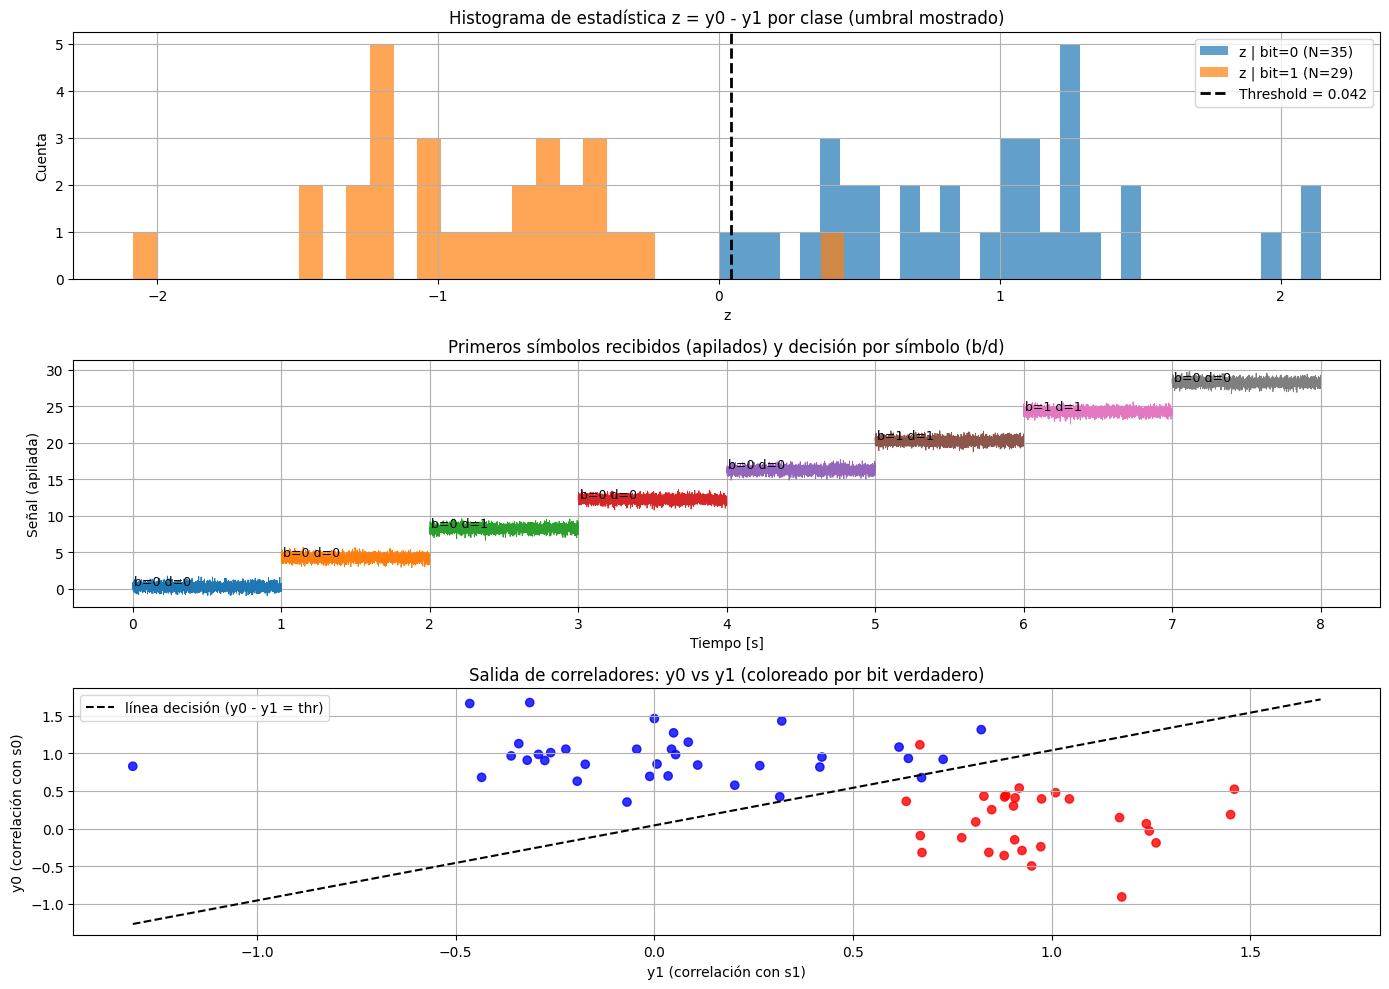

In [14]:
# ----------------- DETECTOR ACOPLADO + UMBRALIZACIÓN -----------------
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Parámetros del experimento (ajustables) ---
N_symbols = 64                   # número de símbolos en la trama
k_offset = 0.25                  # K en el documento (offset factor)
sigma_channel_rel = 0.25         # ruido del canal relativo (multiplica min(D0_amp,D1_amp))
SNR_dB = 10.0                    # SNR objetivo en dB (solo orientativo para ajustar sigma_n)
NORMALIZE_TEMPLATES = True       # ensure templates have unit energy for correlator (opcional)

# --- Preparar plantillas (matched filters) ---
s0 = x0n.clone().double()
s1 = x1n.clone().double()

# opcional: normalizar energía de plantillas para que salida del correlador sea comparable
if NORMALIZE_TEMPLATES:
    E0 = (s0**2).sum()
    E1 = (s1**2).sum()
    s0 = s0 / torch.sqrt(E0)
    s1 = s1 / torch.sqrt(E1)
    E0 = (s0**2).sum()   # ahora =1
    E1 = (s1**2).sum()

# --- Generar secuencia de bits y señal transmitida concatenada ---
bits = torch.randint(0, 2, (N_symbols,))
symbols = []
for b in bits:
    symbols.append(s0 if int(b)==0 else s1)   # use normalized templates as base symbol shapes

# construir señal transmitida concatenada (tiempo continuo, un símbolo tras otro)
tx = torch.cat(symbols)   # length = N_symbols * N (cada symbol length N)
t_tx = np.linspace(0, N_symbols * T_symbol, len(tx))

# --- Canal: offset y AWGN ---
# offset amplitude G = k_offset * min(amp0, amp1) ; use D0_amp, D1_amp from earlier
G = k_offset * min(D0_amp, D1_amp)
offset_vector = G * torch.ones_like(tx)

# calcular sigma de ruido de canal. Estimamos sigma_n con SNR_dB sobre la energía promedio de símbolo
# energía por símbolo (después de normalizar plantillas) -> aproximamos como 1 (si NORMALIZE_TEMPLATES True)
energy_sym = 1.0 if NORMALIZE_TEMPLATES else float(((x0n**2).sum() + (x1n**2).sum())/2.0)
SNR_linear = 10**(SNR_dB/10.0)
sigma_n = np.sqrt(energy_sym / SNR_linear)   # ruido por símbolo
# mezclamos con sigma_channel_rel para simular documento (sigma_eta = sigma_channel_rel * min(D0_amp,D1_amp))
sigma_eta = sigma_channel_rel * min(D0_amp, D1_amp)
# usar una mezcla: sigma_total = sqrt(sigma_n^2 + sigma_eta^2)
sigma_total = np.sqrt(sigma_n**2 + sigma_eta**2)

# generar ruido para toda la trama
noise = sigma_total * torch.randn_like(tx)

# señal recibida
rx = tx + offset_vector + noise

# --- Detector acoplado (ventana por símbolo y correlación) ---
# recorrer símbolo a símbolo; para cada símbolo tomar la ventana correspondiente y correlacionar
y0_list = []
y1_list = []
z_list = []
decisions = []

for i in range(N_symbols):
    start = i * N
    stop = (i+1) * N
    r_seg = rx[start:stop].double()

    # correlación (producto interno) con plantillas (matched filter)
    # si las plantillas tienen unidad de energía, la salida es la proyección
    y0 = torch.dot(r_seg, s0)
    y1 = torch.dot(r_seg, s1)

    y0_list.append(float(y0))
    y1_list.append(float(y1))
    z = float(y0 - y1)
    z_list.append(z)

# estadística z = y0 - y1
z_arr = np.array(z_list)
y0_arr = np.array(y0_list)
y1_arr = np.array(y1_list)

# separar según etiqueta verdadera para estimar distribuciones
z_given0 = z_arr[bits.numpy() == 0]
z_given1 = z_arr[bits.numpy() == 1]

# --- Selección de umbral ---
# Umbral simple: punto medio entre las medias empíricas de z|0 y z|1 (muy efectivo en práctica)
mu0 = z_given0.mean() if len(z_given0)>0 else 0.0
mu1 = z_given1.mean() if len(z_given1)>0 else 0.0
threshold = 0.5 * (mu0 + mu1)

# alternativa: si se desea control de FPR o NP, se podría mover threshold por cuantiles.

# --- Decisiones binarias basadas en z - threshold (decisión: 0 si z > thr => favorece s0)
# Note: Because z = y0 - y1, positive z => prefer s0. So decision rule:
decisions = np.where(z_arr > threshold, 0, 1)

# --- Métricas ---
bits_np = bits.numpy()
conf = confusion_matrix(bits_np, decisions, labels=[0,1])
TN = conf[0,0]; FP = conf[0,1]; FN = conf[1,0]; TP = conf[1,1]
BER = (FP + FN) / float(len(bits_np))
accuracy = (TP + TN) / float(len(bits_np))

# imprimir resultados
print("=== Detector acoplado (matched filter) ===")
print(f"N_symbols = {N_symbols}, N (muestras/símb) = {N}, SNR_dB (target) = {SNR_dB}")
print(f"Offset G = {G:.4f}, sigma_n = {sigma_n:.4e}, sigma_eta = {sigma_eta:.4e}, sigma_total = {sigma_total:.4e}")
print(f"Media z|0 = {mu0:.4f}, Media z|1 = {mu1:.4f}, threshold = {threshold:.4f}")
print("Confusion matrix (rows=verdadero 0/1, cols=decidido 0/1):")
print(conf)
print(f"BER = {BER:.4f}, Accuracy = {accuracy:.4f}")

# --- Plots interpretativos ---
plt.figure(figsize=(14,10))

# 1) Histograma de z por clase con umbral
plt.subplot(3,1,1)
bins = 30
plt.hist(z_given0, bins=bins, alpha=0.7, label=f"z | bit=0 (N={len(z_given0)})")
plt.hist(z_given1, bins=bins, alpha=0.7, label=f"z | bit=1 (N={len(z_given1)})")
plt.axvline(threshold, color='k', linestyle='--', linewidth=2, label=f"Threshold = {threshold:.3f}")
plt.title("Histograma de estadística z = y0 - y1 por clase (umbral mostrado)")
plt.xlabel("z")
plt.ylabel("Cuenta")
plt.legend()
plt.grid(True)

# 2) Ejemplos de símbolos recibidos y salida del correlador (primeros 8 símbolos)
plt.subplot(3,1,2)
n_show = min(8, N_symbols)
for i in range(n_show):
    seg = rx[i*N:(i+1)*N].numpy()
    offset_time = i * T_symbol
    # desplazar verticalmente para ver varios símbolos en la misma trama
    plt.plot(np.linspace(i*T_symbol, (i+1)*T_symbol, N), seg + 4.0*i, linewidth=0.6)
    plt.text(i*T_symbol + 0.01, 4.0*i + 0.5, f"b={bits_np[i]} d={decisions[i]}", fontsize=9)
plt.title("Primeros símbolos recibidos (apilados) y decisión por símbolo (b/d)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Señal (apilada)")
plt.grid(True)

# 3) Scatter de salidas correlador (y1 vs y0) y región de decisión
plt.subplot(3,1,3)
plt.scatter(y1_arr, y0_arr, c=bits_np, cmap='bwr', alpha=0.8)
# dibujar linea y0 - y1 = threshold -> y0 = y1 + threshold
x_vals = np.linspace(min(y1_arr.min(), y0_arr.min()), max(y1_arr.max(), y0_arr.max()), 100)
plt.plot(x_vals, x_vals + threshold, color='k', linestyle='--', label='línea decisión (y0 - y1 = thr)')
plt.xlabel("y1 (correlación con s1)")
plt.ylabel("y0 (correlación con s0)")
plt.title("Salida de correladores: y0 vs y1 (coloreado por bit verdadero)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ----------------- FIN -----------------
